In [1]:
#importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#loading the dataset
uberdataset = pd.read_csv(
    'Uberdataset.csv',
    engine='python',
    encoding='utf-8',
    on_bad_lines='skip'
)

In [3]:
uberdataset.head()

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
0,01-01-2016 21:11,01-01-2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,01-02-2016 01:25,01-02-2016 01:37,Business,Fort Pierce,Fort Pierce,5.0,NaN
2,01-02-2016 20:25,01-02-2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,01-05-2016 17:31,01-05-2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,01-06-2016 14:42,01-06-2016 15:49,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit


In [4]:
uberdataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 1156 entries, 0 to 1155
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   START_DATE  1156 non-null   str    
 1   END_DATE    1155 non-null   str    
 2   CATEGORY    1155 non-null   str    
 3   START       1155 non-null   str    
 4   STOP        1155 non-null   str    
 5   MILES       1156 non-null   float64
 6   PURPOSE     653 non-null    str    
dtypes: float64(1), str(6)
memory usage: 63.3 KB


**DATA CLEANING AND DATA PREPROCESSING**

In [5]:
uberdataset['PURPOSE'] = uberdataset['PURPOSE'].fillna("NOT SPECIFIED")

In [6]:
uberdataset.head()

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
0,01-01-2016 21:11,01-01-2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,01-02-2016 01:25,01-02-2016 01:37,Business,Fort Pierce,Fort Pierce,5.0,NOT SPECIFIED
2,01-02-2016 20:25,01-02-2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,01-05-2016 17:31,01-05-2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,01-06-2016 14:42,01-06-2016 15:49,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit


In [7]:
uberdataset['START_DATE'] = pd.to_datetime(uberdataset['START_DATE'], errors='coerce')

In [8]:
uberdataset['END_DATE'] = pd.to_datetime(uberdataset['END_DATE'], errors='coerce')

In [9]:
uberdataset.head()

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
0,2016-01-01 21:11:00,2016-01-01 21:17:00,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,2016-01-02 01:25:00,2016-01-02 01:37:00,Business,Fort Pierce,Fort Pierce,5.0,NOT SPECIFIED
2,2016-01-02 20:25:00,2016-01-02 20:38:00,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,2016-01-05 17:31:00,2016-01-05 17:45:00,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,2016-01-06 14:42:00,2016-01-06 15:49:00,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit


In [10]:
uberdataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 1156 entries, 0 to 1155
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   START_DATE  421 non-null    datetime64[us]
 1   END_DATE    420 non-null    datetime64[us]
 2   CATEGORY    1155 non-null   str           
 3   START       1155 non-null   str           
 4   STOP        1155 non-null   str           
 5   MILES       1156 non-null   float64       
 6   PURPOSE     1156 non-null   str           
dtypes: datetime64[us](2), float64(1), str(4)
memory usage: 63.3 KB


In [11]:
uberdataset['DATE'] = pd.DatetimeIndex(uberdataset['START_DATE']).date

In [12]:
uberdataset['TIME'] = pd.DatetimeIndex(uberdataset['START_DATE']).time

In [13]:
uberdataset['HOUR'] = pd.DatetimeIndex(uberdataset['START_DATE']).hour

In [14]:
uberdataset.head()

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE,DATE,TIME,HOUR
0,2016-01-01 21:11:00,2016-01-01 21:17:00,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain,2016-01-01,21:11:00,21.0
1,2016-01-02 01:25:00,2016-01-02 01:37:00,Business,Fort Pierce,Fort Pierce,5.0,NOT SPECIFIED,2016-01-02,01:25:00,1.0
2,2016-01-02 20:25:00,2016-01-02 20:38:00,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies,2016-01-02,20:25:00,20.0
3,2016-01-05 17:31:00,2016-01-05 17:45:00,Business,Fort Pierce,Fort Pierce,4.7,Meeting,2016-01-05,17:31:00,17.0
4,2016-01-06 14:42:00,2016-01-06 15:49:00,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit,2016-01-06,14:42:00,14.0


In [15]:
uberdataset['day-night'] = pd.cut(x=uberdataset['HOUR'], bins=[0, 10, 15, 19, 24], labels=['Morning', 'Afternoon', 'Evening', 'Night'])

In [16]:
uberdataset.head()

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE,DATE,TIME,HOUR,day-night
0,2016-01-01 21:11:00,2016-01-01 21:17:00,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain,2016-01-01,21:11:00,21.0,Night
1,2016-01-02 01:25:00,2016-01-02 01:37:00,Business,Fort Pierce,Fort Pierce,5.0,NOT SPECIFIED,2016-01-02,01:25:00,1.0,Morning
2,2016-01-02 20:25:00,2016-01-02 20:38:00,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies,2016-01-02,20:25:00,20.0,Night
3,2016-01-05 17:31:00,2016-01-05 17:45:00,Business,Fort Pierce,Fort Pierce,4.7,Meeting,2016-01-05,17:31:00,17.0,Evening
4,2016-01-06 14:42:00,2016-01-06 15:49:00,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit,2016-01-06,14:42:00,14.0,Afternoon


In [17]:
uberdataset.dropna(inplace=True)

**DATA VISUALIZATION**


<Axes: xlabel='count', ylabel='PURPOSE'>

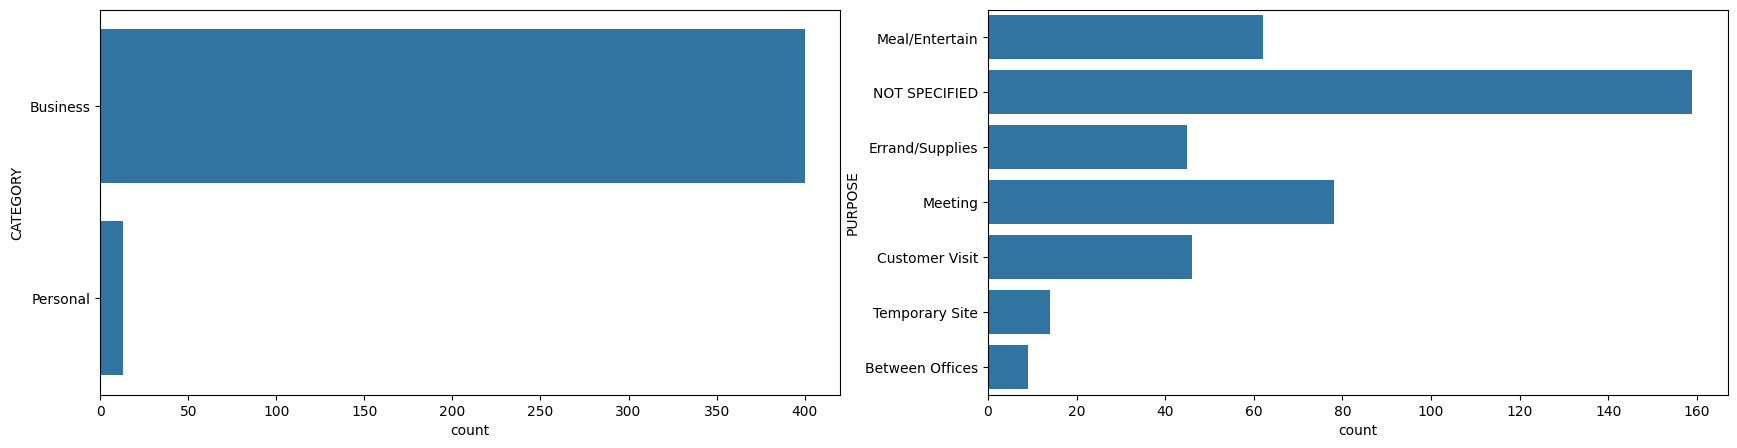

In [18]:
plt.figure(figsize=(21, 5))
plt.subplot(1, 2, 1)
sns.countplot(uberdataset['CATEGORY'])

plt.subplot(1, 2, 2)
sns.countplot(uberdataset['PURPOSE'])

<Axes: xlabel='count', ylabel='day-night'>

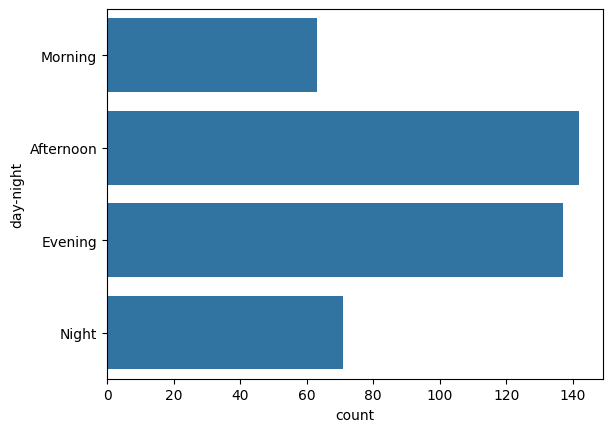

In [19]:
sns.countplot(uberdataset['day-night'])

In [20]:
uberdataset['MONTH'] = pd.DatetimeIndex(uberdataset['START_DATE']).month
month_mapping = {1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun',
                 7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'}
uberdataset['MONTH'] = uberdataset['MONTH'].map(month_mapping)
mon = uberdataset['MONTH'].value_counts(sort=False)

In [21]:
uberdataset.head()

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE,DATE,TIME,HOUR,day-night,MONTH
0,2016-01-01 21:11:00,2016-01-01 21:17:00,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain,2016-01-01,21:11:00,21.0,Night,Jan
1,2016-01-02 01:25:00,2016-01-02 01:37:00,Business,Fort Pierce,Fort Pierce,5.0,NOT SPECIFIED,2016-01-02,01:25:00,1.0,Morning,Jan
2,2016-01-02 20:25:00,2016-01-02 20:38:00,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies,2016-01-02,20:25:00,20.0,Night,Jan
3,2016-01-05 17:31:00,2016-01-05 17:45:00,Business,Fort Pierce,Fort Pierce,4.7,Meeting,2016-01-05,17:31:00,17.0,Evening,Jan
4,2016-01-06 14:42:00,2016-01-06 15:49:00,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit,2016-01-06,14:42:00,14.0,Afternoon,Jan


In [22]:
df = pd.DataFrame({
    "MONTH": mon.values,
    "VALUE COUNT": uberdataset.groupby('MONTH',sort=False)['MILES'].max()
})

[Text(0.5, 0, 'MONTH'), Text(0, 0.5, 'VALUE COUNT')]

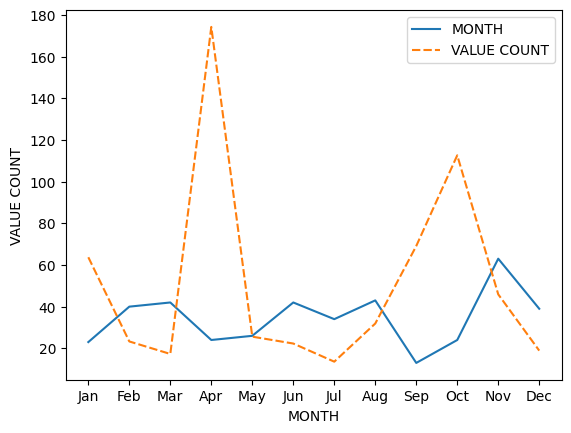

In [23]:
p=sns.lineplot(data=df)
p.set(xlabel='MONTH', ylabel='VALUE COUNT')


In [24]:
uberdataset.head()

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE,DATE,TIME,HOUR,day-night,MONTH
0,2016-01-01 21:11:00,2016-01-01 21:17:00,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain,2016-01-01,21:11:00,21.0,Night,Jan
1,2016-01-02 01:25:00,2016-01-02 01:37:00,Business,Fort Pierce,Fort Pierce,5.0,NOT SPECIFIED,2016-01-02,01:25:00,1.0,Morning,Jan
2,2016-01-02 20:25:00,2016-01-02 20:38:00,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies,2016-01-02,20:25:00,20.0,Night,Jan
3,2016-01-05 17:31:00,2016-01-05 17:45:00,Business,Fort Pierce,Fort Pierce,4.7,Meeting,2016-01-05,17:31:00,17.0,Evening,Jan
4,2016-01-06 14:42:00,2016-01-06 15:49:00,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit,2016-01-06,14:42:00,14.0,Afternoon,Jan


In [25]:
uberdataset['DAY'] = uberdataset.START_DATE.dt.weekday
day_label = {0: 'Mon', 1: 'Tues', 2: 'Wed', 3: 'Thurs', 4: 'Fri', 5: 'Sat', 6: 'Sun'}
uberdataset['DAY'] = uberdataset['DAY'].map(day_label)

In [26]:
uberdataset.head()

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE,DATE,TIME,HOUR,day-night,MONTH,DAY
0,2016-01-01 21:11:00,2016-01-01 21:17:00,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain,2016-01-01,21:11:00,21.0,Night,Jan,Fri
1,2016-01-02 01:25:00,2016-01-02 01:37:00,Business,Fort Pierce,Fort Pierce,5.0,NOT SPECIFIED,2016-01-02,01:25:00,1.0,Morning,Jan,Sat
2,2016-01-02 20:25:00,2016-01-02 20:38:00,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies,2016-01-02,20:25:00,20.0,Night,Jan,Sat
3,2016-01-05 17:31:00,2016-01-05 17:45:00,Business,Fort Pierce,Fort Pierce,4.7,Meeting,2016-01-05,17:31:00,17.0,Evening,Jan,Tues
4,2016-01-06 14:42:00,2016-01-06 15:49:00,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit,2016-01-06,14:42:00,14.0,Afternoon,Jan,Wed


Text(0.5, 1.0, 'Distribution of Trips by Day of the Week')

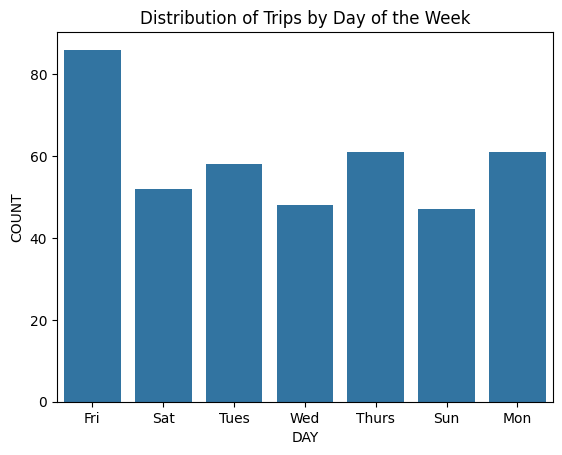

In [27]:
day_label= uberdataset['DAY'].value_counts(sort=False)
sns.barplot(x=day_label.index, y=day_label.values)
plt.xlabel('DAY')
plt.ylabel('COUNT')
plt.title('Distribution of Trips by Day of the Week')

<Axes: ylabel='MILES'>

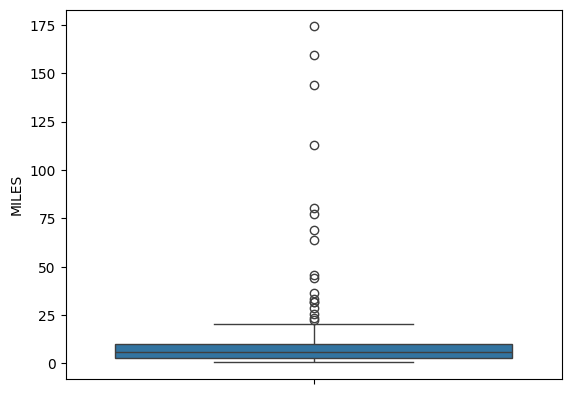

In [28]:
sns.boxplot(uberdataset['MILES'])

<Axes: ylabel='MILES'>

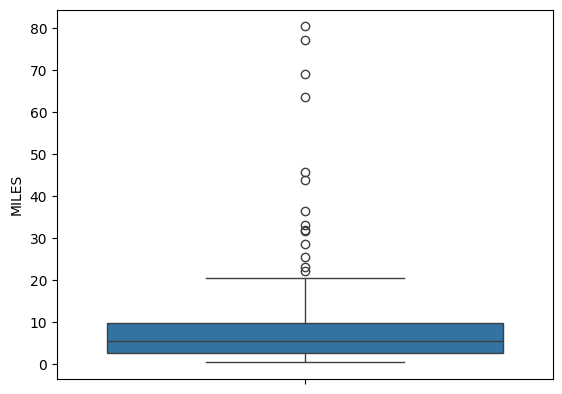

In [29]:
sns.boxplot(uberdataset[uberdataset['MILES'] <100]['MILES'])

C:\Users\NJ\AppData\Local\Temp\ipykernel_27416\2063995601.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(uberdataset[uberdataset['MILES'] < 40]['MILES'])


<Axes: xlabel='MILES', ylabel='Density'>

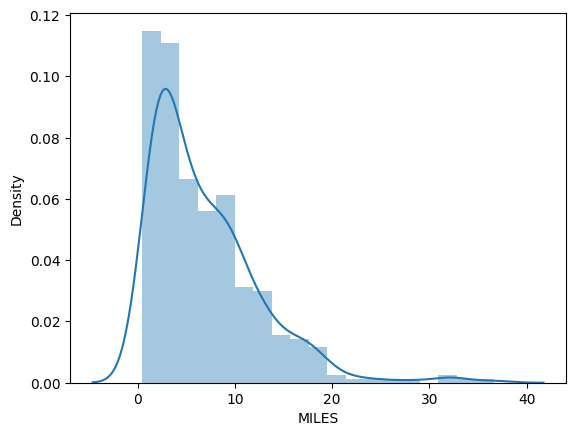

In [30]:
sns.distplot(uberdataset[uberdataset['MILES'] < 40]['MILES'])

**1. In which category do people book the most Uber rides?**

: People book the most Uber rides in the Business category. The number of business rides is significantly higher than personal rides, indicating that Uber is primarily used for work-related travel in this dataset.

**2. For which purpose do people book Uber rides the most?**

: The most common purpose for Uber rides is "NOT SPECIFIED". Among the rides with a specified purpose, Meeting is the most frequent reason for booking an Uber ride, followed by Meal/Entertainment.

**3. At what time do people book cabs the most from Uber?**

: People book Uber rides the most during the Afternoon, with the Evening being a close second. The Morning has the lowest number of bookings among the four time periods.

**4. In which months do people book Uber rides less frequently?**

: People book Uber rides least frequently in July, which records the lowest ride count. Other months with relatively low booking frequencies include March, December, June, and February. In contrast, April has the highest number of bookings, followed by October.

**5. On which days of the week do people book Uber rides the most?**

: People book Uber rides the most on Friday. Monday and Thursday have the second-highest number of bookings, indicating high demand at both the beginning and toward the end of the workweek.

**6. How many miles do people usually book a cab for through Uber?**

: Most Uber rides are booked for short distances between 0 and 10 miles. The distribution plot peaks within this range and gradually decreases as the trip distance increases, showing that longer rides are less common.